# ============================================
### Title: Assignment 1.2
### Author: Doug Nolan
### Date: 9 June 2026
### Modified By: Doug Nolan
### Description: this program explores pandas dataframe. we grab video game data and play with it. Find some top 5 rows by different columns. replace null values and calculate a median user score
# ============================================


In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("meruvakodandasuraj/formula-1-race-intelligence-20102026")

print("Path to dataset files:", path)

100%|██████████████████████████████████████████████████████████████████████████████████| 402k/402k [00:00<00:00, 9.36MB/s]

Extracting files...
Path to dataset files: /Users/doug/.cache/kagglehub/datasets/meruvakodandasuraj/formula-1-race-intelligence-20102026/versions/1


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("/Users/doug/DSC 550/championship_standings.csv")

print(df.head(10))

   season  driver_position           driver             team  points  wins  \
0    2010                1   Max Verstappen  Red Bull Racing     306     8   
1    2010                2     Sergio Perez  Red Bull Racing     244     0   
2    2010                3     Lando Norris          McLaren     226     4   
3    2010                4    Oscar Piastri          McLaren     199     0   
4    2010                5  Charles Leclerc          Ferrari     166     3   
5    2010                6     Esteban Ocon           Alpine     153     1   
6    2010                7     Carlos Sainz          Ferrari     143     0   
7    2010                8     Pierre Gasly           Alpine     117     0   
8    2010                9   Lewis Hamilton         Mercedes      52     0   
9    2010               10   George Russell         Mercedes      31     0   

   podiums  pole_positions  dnfs  champion  
0       13               8     1         1  
1        9               0     0         0  
2     

# introduction explaining the data set
- f1 race intelligence 2010-2026
- f1 is a racing league. these are the results for the last 17 years.
- includes end of year standings for all racers and teams
- count of wins, podiums, pole positions, dnf (did not finish), and champion

# question to explore in the data set

- who has been the most dominate the last 17 years? (spoiler, probably Lewis Hamilton)
- what driver has won the most races
- what driver has won the most championships
- what team has won the most championships


# 3 graphs to answer these questions - label graphs professionally


In [2]:
# set default graph settings
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12,6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13

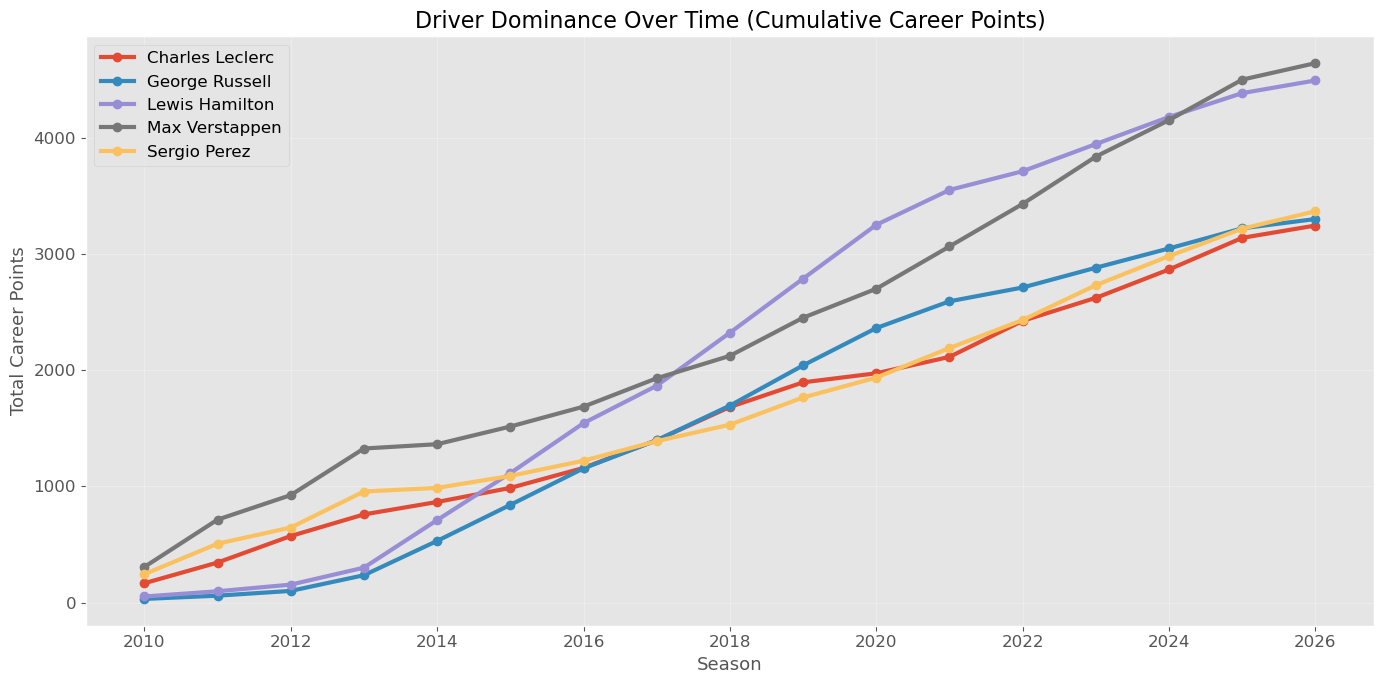

In [3]:
# yearly cumulative points by driver
yearly_points = df.groupby(["season","driver"])["points"].sum().reset_index()

# top 5 drivers overall
top_drivers = (
    df.groupby("driver")["points"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
    .index
)

filtered = yearly_points[yearly_points["driver"].isin(top_drivers)]

pivot = filtered.pivot(
    index="season",
    columns="driver",
    values="points"
).fillna(0)

cumulative = pivot.cumsum()

plt.figure(figsize=(14,7))

for driver in cumulative.columns:
    plt.plot(
        cumulative.index,
        cumulative[driver],
        marker="o",
        linewidth=3,
        label=driver
    )

plt.title("Driver Dominance Over Time (Cumulative Career Points)")
plt.xlabel("Season")
plt.ylabel("Total Career Points")
plt.legend()
plt.grid(alpha=.3)

plt.tight_layout()
plt.show()

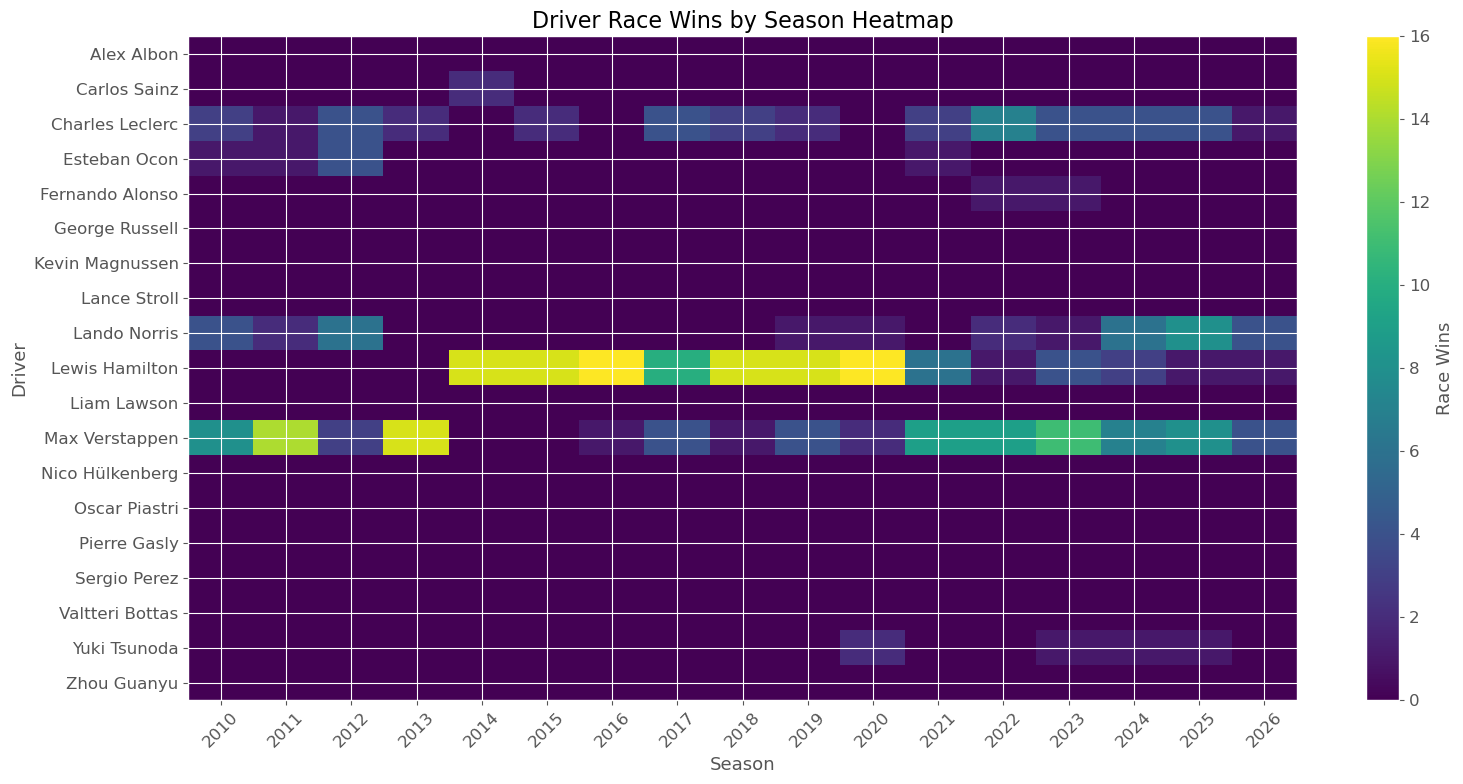

In [4]:
wins = df.pivot_table(
    index="driver",
    columns="season",
    values="wins",
    aggfunc="sum"
)

plt.figure(figsize=(16,8))

plt.imshow(wins.fillna(0), aspect="auto")

plt.colorbar(label="Race Wins")

plt.yticks(range(len(wins.index)), wins.index)
plt.xticks(range(len(wins.columns)), wins.columns, rotation=45)

plt.title("Driver Race Wins by Season Heatmap")
plt.xlabel("Season")
plt.ylabel("Driver")

plt.tight_layout()
plt.show()

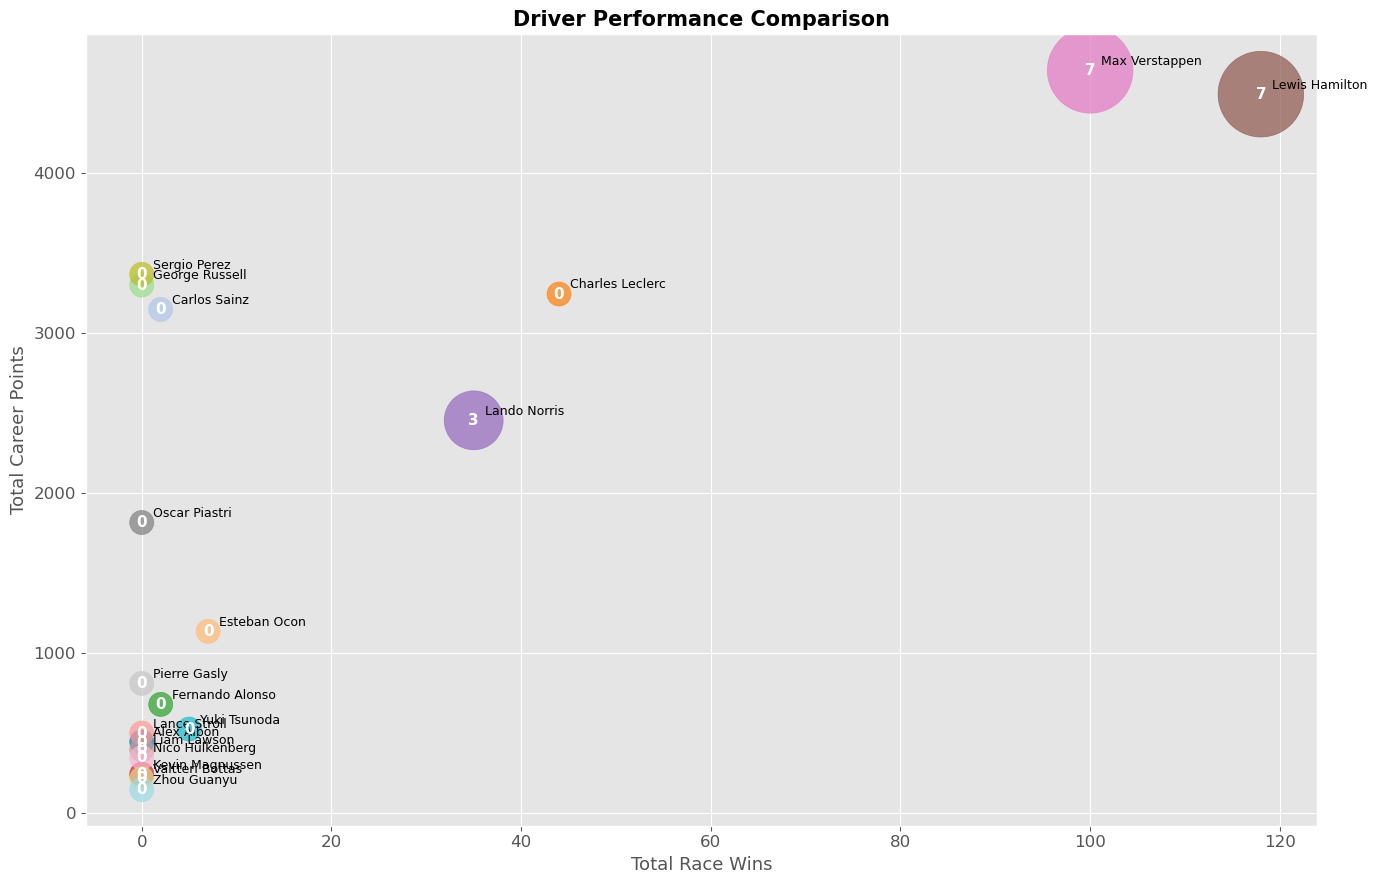

In [12]:
# Aggregate data by driver
driver_summary = df.groupby("driver").agg({
    "wins": "sum",
    "points": "sum"
})

# Count championships won
titles = (
    df[df["champion"] == 1]
    .groupby("driver")
    .size()
)

driver_summary["titles"] = titles
driver_summary["titles"] = driver_summary["titles"].fillna(0)

plt.figure(figsize=(14, 9))

# Create different colors for each driver - personal preference :) 
colors = plt.cm.tab20(np.linspace(0, 1, len(driver_summary)))

# Scatter plot
plt.scatter(
    driver_summary["wins"],
    driver_summary["points"],
    s=driver_summary["titles"] * 500 + 300,   # slightly larger bubbles
    c=colors,
    alpha=0.7
)

# Add title count INSIDE bubble
for driver in driver_summary.index:
    x = driver_summary.loc[driver, "wins"]
    y = driver_summary.loc[driver, "points"]
    titles = int(driver_summary.loc[driver, "titles"])

    # championship count inside bubble
    plt.text(
        x, y, str(titles),
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="white"
    )

    # driver name next to bubble
    plt.annotate(
        driver,
        (x, y),
        xytext=(8, 4),           # offset from bubble
        textcoords="offset points",
        fontsize=9
    )

plt.title("Driver Performance Comparison", fontsize=15, fontweight="bold")
plt.xlabel("Total Race Wins")
plt.ylabel("Total Career Points")

plt.tight_layout()
plt.show()

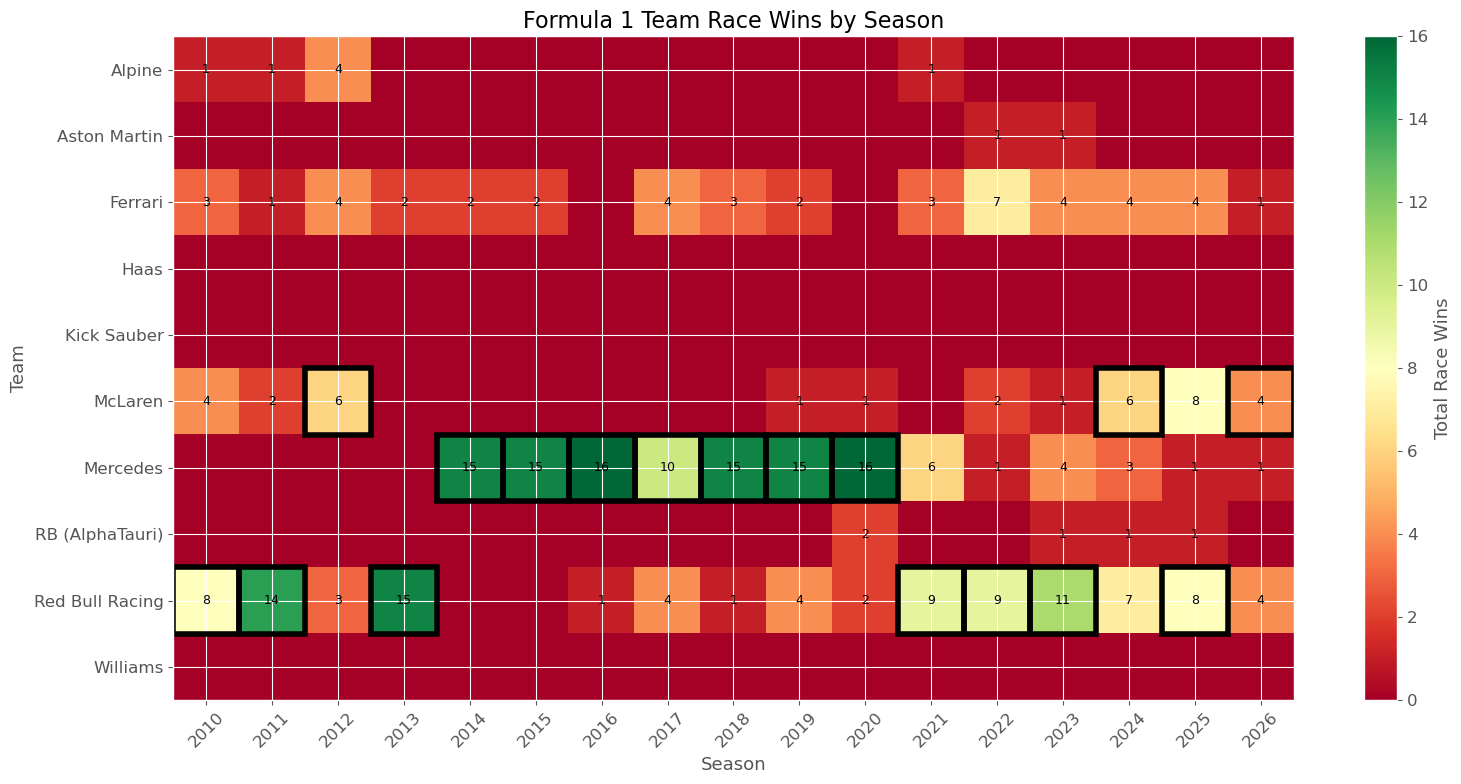

In [15]:
# Total wins by team per season
team_wins = df.pivot_table(
    index="team",
    columns="season",
    values="wins",
    aggfunc="sum"
).fillna(0)

# Championship team each season
champion_teams = (
    df[df["driver_position"] == 1]
    .groupby("season")["team"]
    .first()
)

fig, ax = plt.subplots(figsize=(16,8))

# Main heatmap
heatmap = ax.imshow(
    team_wins,
    aspect="auto",
    cmap="RdYlGn"
)

# Color bar
cbar = plt.colorbar(heatmap)
cbar.set_label("Total Race Wins")

# Labels
ax.set_xticks(np.arange(len(team_wins.columns)))
ax.set_yticks(np.arange(len(team_wins.index)))

ax.set_xticklabels(team_wins.columns, rotation=45)
ax.set_yticklabels(team_wins.index)

plt.title("Formula 1 Team Race Wins by Season")
plt.xlabel("Season")
plt.ylabel("Team")
for i in range(len(team_wins.index)):
    for j in range(len(team_wins.columns)):

        value = int(team_wins.iloc[i, j])

        if value > 0:
            ax.text(
                j,
                i,
                value,
                ha="center",
                va="center",
                fontsize=9,
                color="black"
            )

for season, champion_team in champion_teams.items():

    col = list(team_wins.columns).index(season)

    if champion_team in team_wins.index:

        row = list(team_wins.index).index(champion_team)

        # Black rectangle around champion
        rect = plt.Rectangle(
            (col - 0.5, row - 0.5),
            1,
            1,
            fill=False,
            edgecolor="black",
            linewidth=4
        )

        ax.add_patch(rect)

plt.tight_layout()
plt.show()

# explain findings from graphs

# Graph 1 - Driver dominance over time (cumulative career points) 
- this line graph shows how many points the top 5 drivers go each year, as a running total. 
- The different color lines make it easy to follow and match to the legend at the top left
- the y axis is the amount of points each driver has earned
- the x axis the the year of the racing season
- the overall results - starting is 2015 you can see Lewis and Max start to separate themselves from the rest.
- the split gets even wider from the larger group in 2022
- Max keeps his upward trajectory of points pretty consistent
- while Lewis has a steep fall off in the 2022-current seasons

# Graph 2 - heatmap of driver race wins by season
- the y axis is race driver
- the x axis the the year of the racing season
- the overall results Max and Lewis have the brightest colors, indicating they've typically won the most races in a given season
- Charles is sneaking into 3rd place most years

# Graph 3 - Driver performance Comparison
- X axis is the amount of race wins a driver has
- Y axis is the amount of points they have earned. You get points by finishing in places 1-10 out of a field of 20 racers
- the bubbles represent each driver, the size of the bubble corresponds to the amount of championships they have won
- Charles has a lot of wins and even more points, but sadly no championships
- Lando has 3 championships in his young career, seems like potential to catch Max and Lewis at 7 championships
- Max and Lewis are the best drivers, hands down
- the outliers at the top left - these drivers have earned a lot of points (top 10 finishes), but not a proportionate amount of wins
- in fact, Carlos Sainz is the only one from that group that has a win yet. 

# Graph 4 - Formula 1 Team Race Wins by Season
- the X axis is the year of the racing season
- the Y axis the different racing teams. there are 10 teams with 2 drivers on each team
- I immediately spot 2 different dynsastys (winning streaks) from teams.
- Mercedes 2014-2020
- Red Bull 2021-2025 (minus the 2024 season) 
- in the 17 years of racing data, there have only been 3 different teams to win the championship
- a few teams, Haas, Kick Sauber, Williams have not netted any wins at all 

# summarize findings in conclusion


### I was able to modify the data and create the right (and exciting) visuals to answer the questions.
### The first few graphs focused on individual drivers. How many points they earned, races and championships won
### The last graph showed team results. Majorly skewed - only 3 different teams have won the championship since 2010